In [1]:
import kagglehub
from PIL import Image
import torch
import matplotlib.pyplot as plt
from models.mlp import run
import util

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
path = "./normalized_images"

num_epochs = 10
lr = 1e-4

model, train_losses, eval_losses, eval_preds, eval_labels = run(path, device, num_epochs=num_epochs, lr=lr)

-- MLP | Epochs: 10 | LR: 0.0001
Epoch 1/10 - Train Loss: 1.1735, Eval Loss: 0.3930
Epoch 2/10 - Train Loss: 0.4168, Eval Loss: 0.2799
Epoch 3/10 - Train Loss: 0.3145, Eval Loss: 0.2257
Epoch 4/10 - Train Loss: 0.2936, Eval Loss: 0.2476
Epoch 5/10 - Train Loss: 0.2566, Eval Loss: 0.2160
Epoch 6/10 - Train Loss: 0.2512, Eval Loss: 0.2087
Epoch 7/10 - Train Loss: 0.2417, Eval Loss: 0.2136
Epoch 8/10 - Train Loss: 0.2395, Eval Loss: 0.2102
Epoch 9/10 - Train Loss: 0.2300, Eval Loss: 0.2030
Epoch 10/10 - Train Loss: 0.2271, Eval Loss: 0.2100
Training time: 480.830s
Score Train: 0.878 | Score Test: 0.887


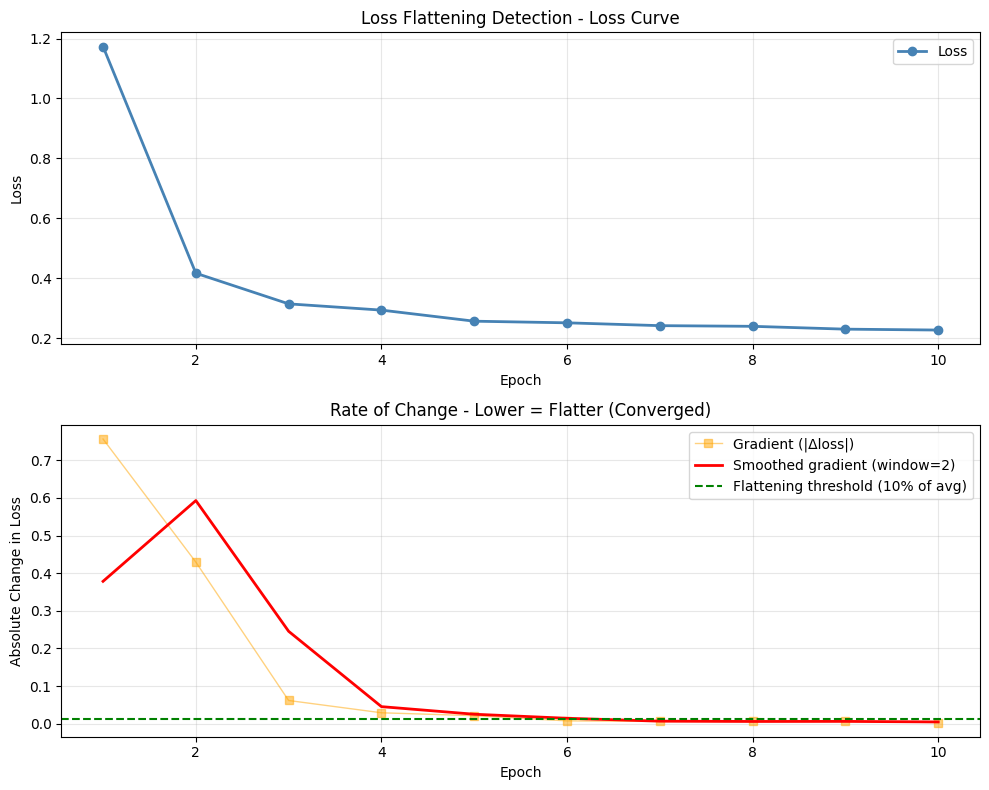


✓ Loss appears to flatten starting around epoch 7


In [6]:
from graphs import plot_loss_flattening
plot_loss_flattening(train_losses, window_size=2)

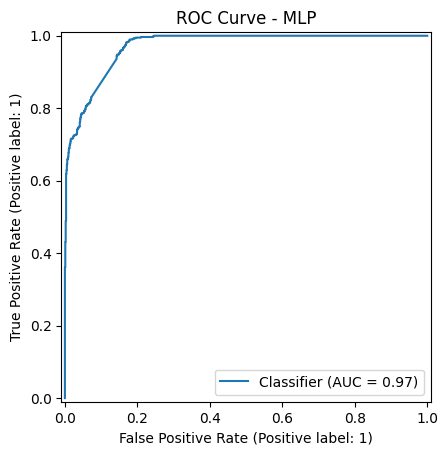

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(eval_labels, eval_preds)
plt.title("ROC Curve - MLP")
plt.show()

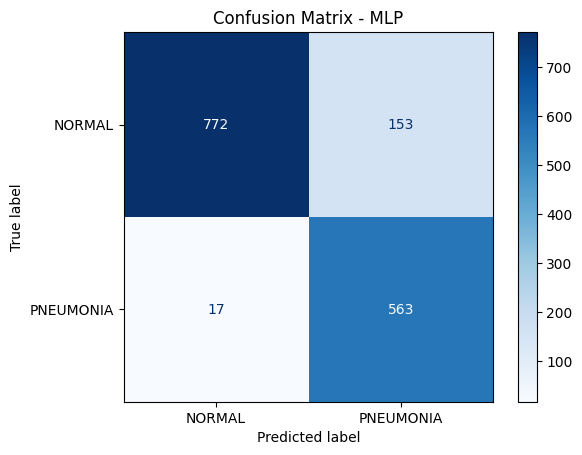

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.show()